In [21]:
from __future__ import annotations

import numpy as np
import pandas as pd
from legendtestdata import LegendTestData

from lgdo.lh5 import LH5Iterator

ldata = LegendTestData()

# directories and channels we will be reading from...
lh5_hit_dir = ldata.get_path("lh5/prod-ref-l200/generated/tier/hit/cal/p03/r001/")
lh5_dsp_dir = ldata.get_path("lh5/prod-ref-l200/generated/tier/dsp/cal/p03/r001/")
channels = ["ch1084803", "ch1084804", "ch1121600"]

In [22]:
lh5_it = LH5Iterator(
    lh5_files=f"{lh5_hit_dir}/*.lh5",  # all files in directory
    groups=[f"{ch}/hit" for ch in channels],  # hit table for all channels
    field_mask=["is_valid_cal", "cuspEmax_ctc_cal"],  # read only these fields
    buffer_len=20,  # read 20 entries at a time; default reads 100 MB worth of entries
)

# Loop over each chunk, and show the tables
pd.set_option("display.max_rows", 6)
for tb in lh5_it:
    display(tb.view_as("pd"))
pd.reset_option("display.max_rows")

,is_valid_cal,cuspEmax_ctc_cal
0,True,331.728593
1,True,371.712149
2,True,68.957137
...,...,...
17,False,761.547472
18,False,511.064827
19,True,406.808486


,is_valid_cal,cuspEmax_ctc_cal
0,True,223.558627
1,True,272.818865
2,True,135.868696
...,...,...
17,False,140.007839
18,True,432.960866
19,True,143.123212


,is_valid_cal,cuspEmax_ctc_cal
0,False,2252.397663
1,True,1415.206464
2,True,186.421123
...,...,...
17,True,96.902142
18,True,239.531337
19,True,63.866863


In [23]:
outputs = []
for tb in lh5_it:
    df = tb.view_as("pd")
    df["file"] = lh5_it.current_files
    df["group"] = lh5_it.current_groups
    df = df.query("is_valid_cal and cuspEmax_ctc_cal>500")
    outputs += [df]
df = pd.concat(outputs)
display(df)

,is_valid_cal,cuspEmax_ctc_cal,file,group
5,True,583.031777,/tmp/legend-testdata-ge95wuj/data/lh5/prod-ref...,ch1084803/hit
10,True,2599.263988,/tmp/legend-testdata-ge95wuj/data/lh5/prod-ref...,ch1084804/hit
12,True,2614.267720,/tmp/legend-testdata-ge95wuj/data/lh5/prod-ref...,ch1084804/hit
13,True,584.749996,/tmp/legend-testdata-ge95wuj/data/lh5/prod-ref...,ch1084804/hit
6,True,604.976935,/tmp/legend-testdata-ge95wuj/data/lh5/prod-ref...,ch1121600/hit
15,True,617.254403,/tmp/legend-testdata-ge95wuj/data/lh5/prod-ref...,ch1084803/hit
16,True,582.929879,/tmp/legend-testdata-ge95wuj/data/lh5/prod-ref...,ch1084803/hit
1,True,1415.206464,/tmp/legend-testdata-ge95wuj/data/lh5/prod-ref...,ch1084804/hit
7,True,582.349982,/tmp/legend-testdata-ge95wuj/data/lh5/prod-ref...,ch1084804/hit


In [24]:
# Construct two iterators, with the second one a "friend" of the first
lh5_it = LH5Iterator(
    lh5_files=f"{lh5_hit_dir}/*.lh5",  # all files in hit tier directory
    groups=[f"{ch}/hit" for ch in channels],  # hit table for all channels
    field_mask=["is_valid_cal", "cuspEmax_ctc_cal"],  # read only these fields
    buffer_len=20,  # read 20 entries at a time; default reads 100 MB worth of entries
    friend=LH5Iterator(
        lh5_files=f"{lh5_dsp_dir}/*.lh5",  # all files in dsp tier directory
        groups=[f"{ch}/dsp" for ch in channels],  # dsp table for all channels
        field_mask=["tp_0_est", "tp_90"],
    ),
)

# Display events from both data tiers, with long drift times
outputs = []
for tb in lh5_it:
    df = tb.view_as("pd")
    df = df.query("is_valid_cal and (tp_90 - tp_0_est)>1000")
    outputs += [df]
df = pd.concat(outputs)
display(df)

,is_valid_cal,cuspEmax_ctc_cal,tp_0_est,tp_90
2,True,68.957137,47360.0,49392.0
4,True,178.605856,47776.0,48864.0
9,True,199.588118,47632.0,48752.0
10,True,2599.263988,47600.0,48736.0
12,True,2614.267720,47632.0,48752.0
15,True,617.254403,47376.0,49504.0
16,True,582.929879,47712.0,48816.0
7,True,582.349982,47744.0,48768.0


In [25]:
lh5_hit_dir = ldata.get_path("lh5/prod-ref-l200/generated/tier/hit/cal/p03/r001/")
channels = ["ch1084803", "ch1084804", "ch1121600"]
chan_data = {
    "chanid": [1084803, 1084804, 1121600],
    "detname": ["huey", "dewey", "louie"],
}

# set group_data with our channel metadata
lh5_it = LH5Iterator(
    lh5_files=f"{lh5_hit_dir}/*.lh5",  # all files in hit tier directory
    groups=[f"{ch}/hit" for ch in channels],  # hit table for all channels
    field_mask=["is_valid_cal", "cuspEmax_ctc_cal"],  # read only these fields
    group_data=chan_data,  # attach our channel metadata
    buffer_len=20,  # read 20 entries at a time; default reads 100 MB worth of entries
)

# We're going to be fancy with our loop this time...
outputs = []
for tb in lh5_it:
    df = tb.view_as("pd")
    df = df.query("is_valid_cal and cuspEmax_ctc_cal>500")
    outputs += [df]
df = pd.concat(outputs)
display(df)

,is_valid_cal,cuspEmax_ctc_cal,chanid,detname
5,True,583.031777,1084804,dewey
10,True,2599.263988,1084804,dewey
12,True,2614.267720,1084804,dewey
13,True,584.749996,1084804,dewey
6,True,604.976935,1084803,huey
15,True,617.254403,1084803,huey
16,True,582.929879,1084803,huey
1,True,1415.206464,1121600,louie
7,True,582.349982,1121600,louie


In [26]:
lh5_it = LH5Iterator(
    lh5_files=f"{lh5_hit_dir}/*.lh5",  # all files in directory
    groups=[f"{ch}/hit" for ch in channels],  # hit table for all channels
    field_mask=["is_valid_cal", "cuspEmax_ctc_cal"],  # read only these fields
    buffer_len=20,  # read 20 entries at a time; default reads 100 MB worth of entries
)
df = lh5_it.query("is_valid_cal & (cuspEmax_ctc_cal>500)", library="pd")
display(df)


,is_valid_cal,cuspEmax_ctc_cal
0,True,583.031777
1,True,2599.263988
2,True,2614.267720
3,True,584.749996
4,True,604.976935
5,True,617.254403
6,True,582.929879
7,True,1415.206464
8,True,582.349982


In [27]:
df = lh5_it.query("is_valid_cal & (cuspEmax_ctc_cal>500)", processes=3, library="pd")
display(df)

,is_valid_cal,cuspEmax_ctc_cal
0,True,583.031777
1,True,2599.263988
2,True,2614.267720
3,True,584.749996
4,True,604.976935
5,True,617.254403
6,True,582.929879
7,True,1415.206464
8,True,582.349982


In [28]:
from hist import axis

h = lh5_it.hist(
    axis.Regular(30, 0, 3000, label="Energy (keV)"),
    where="is_valid_cal",
    keys="cuspEmax_ctc_cal",
)
display(h)

Hist(Regular(30, 0, 3000, label='Energy (keV)'), storage=Double()) # Sum: 53.0

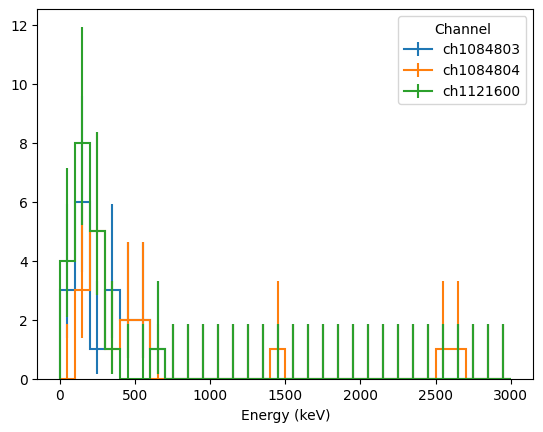

In [29]:
# Select valid events and return energy and channel name
def selector(lh5_tb, lh5_it):
    df = lh5_tb.view_as("pd")
    mask = df.is_valid_cal
    E_col = df.cuspEmax_ctc_cal[mask]
    chan_col = lh5_it.current_groups[mask]
    chan_col = np.strings.replace(chan_col, "/hit", "")

    return E_col, chan_col


# 2D histogram with a categorical axis
h = lh5_it.hist(
    [
        axis.Regular(30, 0, 3000, label="Energy (keV)"),
        axis.StrCategory([], growth=True, label="Channel"),
    ],
    where=selector,
)
h.plot1d();